In [63]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [64]:
%reload_ext autoreload

In [1]:
from langgraph.graph import StateGraph, END, add_messages
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage, AIMessage, ToolMessage
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

from agent_setup import build_agent, call_agent
from tools.registry import get_tools
from workflow import build_workflow
from nodes import tool_node, agent_node

from dotenv import load_dotenv
import json

from functools import partial

load_dotenv()

x:\Langraph\Projects\voice_assisted_file_opener\venv\Lib\site-packages\langchain_core\utils\pydantic.py:42: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1


True

### PROMPTS

In [2]:
from prompts.base_prompt import base_prompt
from prompts.apps_files_prompt import apps_files_prompt
from prompts.folder_prompt import folder_prompt 
from policies import safety_policy

### AGENT SETUP

In [3]:
prompt = ChatPromptTemplate.from_messages([
    ("system", 
    f"""
    1. General Instructions:
        {base_prompt}
    \n

    2. Safety Instructions:
        {safety_policy}

    3. Tool Instructions:

    a. Applications/Files Tools:
        {apps_files_prompt} 
        \n 
    b. Folder Tools:
        {folder_prompt}
        \n
    """),
    MessagesPlaceholder(variable_name="messages")
])

In [4]:
from llm import init_llm
from state import AssistantState

llm = init_llm()
tool_reg = get_tools()
tools = tool_reg['tool_objs']
agent = build_agent(llm=llm, prompt=prompt, tools=tools)
call_agent_node = agent_node(agent)

nodes = {
    "Tool": tool_node,
    "Agent": call_agent_node
}

checkpointer = MemorySaver()

workflow = build_workflow(nodes=nodes, checkpointer=checkpointer)

### Testing

In [40]:
test_state: AssistantState = ({
    "messages": [HumanMessage("List the contents of X:")]
})

# "messages" is passed to MessagePlaceholder in the prompt
response = call_agent(test_state)

test_state['messages'] = add_messages(test_state['messages'], response['messages'])

print(response)

{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'function': {'arguments': '{"path": "X:\\\\"}', 'name': 'list_subdirs_tool', 'description': None}, 'id': 'chatcmpl-tool-cac4815c641649c2a68c6f7a433cafc5', 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 2815, 'total_tokens': 2839}, 'model_name': 'Qwen/Qwen3-Coder-Next', 'system_fingerprint': '', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a05371-b46e-79e1-96f6-e4f8139194c6-0', tool_calls=[{'name': 'list_subdirs_tool', 'args': {'path': 'X:\\'}, 'id': 'chatcmpl-tool-cac4815c641649c2a68c6f7a433cafc5', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2815, 'output_tokens': 24, 'total_tokens': 2839})]}


##### Extract tool call

In [43]:
tool_call = response['messages'].tool_calls[-1]
print("Tool Call:", tool_call)

tool_res = tool_names[tool_call['name']].invoke(tool_call['args'])
print("Tool Result:", tool_res)

tool_message = ToolMessage(
    content=json.dumps(tool_res),
    name=tool_call['name'],
    tool_call_id = tool_call['id']
)

test_state['messages'] = add_messages(test_state['messages'], [tool_message])

AttributeError: 'list' object has no attribute 'tool_calls'

In [ ]:
print(test_state['messages'])

[HumanMessage(content='Open file explorer', additional_kwargs={}, response_metadata={}, id='1bb5ab21-52a3-4d8e-806e-3eb5732c770a'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'try_direct_open', 'arguments': '{"name": "File Explorer"}'}, '__gemini_function_call_thought_signatures__': {'a214ec18-7478-495d-bbc8-c00f79d5e5da': 'CuMDARFNMg/a63VslH1O4UIMhWgkUJgk0mLSNNvS3VsXD+wWeZ8vyOFL4VAmL/YFlHkqvECJtDLFGmcGUmvSOCFQgr69XVxd5XbAnaTFy9SAVamRe+3soCEQMUmEC2IQbGKAIakxRGJVwmjw8Wd8b/5UWUUrEQoLpsS9Jji/G8Jcm9Qu7dNBwuqvNuw9UXIruXsynzQEK9MKZmhlJ/Y0q8etK4UL2lDQQ0qMZFCQ8KuorVESkbHINkm8uexnL+OayRBQK/MCKw4dWMWX3AzdWM9firYnY4IzqhNPgq0Qx2KXSKpfbSixX0c+CpO+kzdkjuC+xWQOzH9miiEcOOux9vzKwCaj8kbsMhRYy/YpEdCovRvSBjy4V6NINOj3oQRbgyLnJh0iNSP4QE/VMavYy7GeVAzNY8NN98Syuc2dF3o5Obi2248BiBUkj8qRe5S9lVwWp3kvVrapf0AlqtRuOL69WW5urzIAMb1Rzblv5r32HaopewNAsekmSUNB0Y5uLZrbgmO5AFsJfQRFRyE/Fxu3rPg6/T6TsCaWz6/R3sU/oe5f8r1sL6Yb26Q+FBkpxQDZJboQwIXniR9Te0sYE9XdWn9WW4TmwAdoiJAc/h9bERMJ/dQuxl1+Cd5cnszaI2sXhb8m'}

### CREATE WORKFLOW

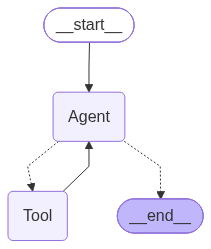

In [25]:
from IPython.display import Image
Image(voice_agent.get_graph().draw_mermaid_png())

In [5]:
# audio_file = record_audio()

# text = speech_to_text(audio_file)
# print("Prompt:", text)

config = {
    "configurable": {
        "thread_id": 123
    }
}

def action(text: str):
    test_state: AssistantState = ({
    "messages": [HumanMessage(text)]
    })

    result = workflow.invoke(test_state, config=config)
    if "__interrupt__" in result:
        user_in = input("YES / NO?: ")
        result = workflow.invoke(
            Command(resume=user_in),
            config=config
        )

    return result

In [7]:
print("Hello!... How can I help you:\n")
while True:
    user_in = input("")

    if user_in in ["exit", "quit", "e", "q"]:
        print("Exited successfully")
        break

    result = action(user_in)
    print(result["messages"][-1].content)
    print("\n\n")
    print(result)

# print(action(user_in))
# print(result)

Hello!... How can I help you:

Notepad has been opened.



{'messages': [HumanMessage(content='open notepad', additional_kwargs={}, response_metadata={}, id='b5b0e761-46ea-492e-b39f-ec280e039381'), HumanMessage(content='open notepad', additional_kwargs={}, response_metadata={}, id='10d7d8da-8fcb-41b9-b1e9-e710fe4b7731'), AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user wants to open Notepad. Let me check the available tools. The first step is to try opening the application directly. The tool \'try_direct_open\' is for that. The argument needed is the name, which in this case is "notepad". I should call that function. If that fails, maybe try the shortcut or index search, but since Notepad is a common app, direct open should work. Let me make sure the name is correct. The user said "open notepad", so the name parameter is "notepad". I\'ll use try_direct_open with name "notepad".\n', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index

In [10]:
for message in result["messages"]:
    if isinstance(message, AIMessage):
        print(message)
        break

content='' additional_kwargs={'reasoning_content': 'Okay, the user wants to open Notepad. Let me check the available tools. The first step is to try opening the application directly. The tool \'try_direct_open\' is for that. The argument needed is the name, which in this case is "notepad". I should call that function. If that fails, maybe try the shortcut or index search, but since Notepad is a common app, direct open should work. Let me make sure the name is correct. The user said "open notepad", so the name parameter is "notepad". I\'ll use try_direct_open with name "notepad".\n', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'Okay, the user wants to open Notepad. Let me check the available tools. The first step is to try opening the application directly. The tool \'try_direct_open\' is for that. The argument needed is the name, which in this case is "notepad". I should call that function. If that fails, maybe try the shortcut or index sear

In [58]:
test_state: AssistantState = ({
    "messages": [HumanMessage("Remove folder abc from X:/")]
    })

workflow.invoke(test_state, config=config)


close_app
get_running_apps_tool
open_web_search
remove_file
try_direct_open
try_index_open
try_shortcut_open
close_folder_by_path
create_directory
find_directory
list_drives
list_open_folders
list_subdirs_tool
open_folder_direct
open_folder_via_index
open_known_folder
remove_dir
Tool Call: {'name': 'remove_dir', 'args': {'path': 'X:/abc'}, 'id': 'call-ed0ce1e2-d0f1-400a-8ad5-99c17517904e', 'type': 'tool_call'}


{'messages': [HumanMessage(content='Remove folder abc from X:/', additional_kwargs={}, response_metadata={}, id='10cc71f1-9a60-45c0-bbcc-14562f2e5ef9'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to remove folder abc from X:/. The user says "Remove folder abc from X:/". Likely they want to delete folder abc located at X:\\abc. We need to ensure path exists? We can try to remove directory using remove_dir with path "X:/abc". However, we need to be careful: The tool expects a valid path. We should first maybe check if folder exists? There\'s no tool to check existence directly, but we can try to remove and see result. If it fails, we report failure.\n\nWe should also consider safety: folder deletion is destructive; we need explicit user confirmation? The policy says before executing a deletion, the application should require explicit user confirmation through the application\'s human-in-the-loop mechanism when confirmation is required by the system\'s safety

In [ ]:
user_input = input("Y / N?: ")
workflow.invoke(
    Command(resume=user_input),
    config=config)

Tool Call: {'name': 'remove_dir', 'args': {'path': 'X:\\abc'}, 'id': 'chatcmpl-tool-14a6203111e841f5bd777aadae1723a1', 'type': 'tool_call'}


{'messages': [HumanMessage(content='close abc', additional_kwargs={}, response_metadata={}, id='671f5969-abed-416f-9e29-d46edb3bbba3'),
  AIMessage(content='I\'ll close the application named "abc" for you.', additional_kwargs={'reasoning_content': 'The user wants to close an application named "abc". I need to use the close_app tool to close this application. Let me first check what applications are running to see if "abc" is actually running, and then close it.\n\nActually, I should just try to close it directly since the user is asking to close it. Let me use the close_app tool with the name "abc".', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'The user wants to close an application named "abc". I need to use the close_app tool to close this application. Let me first check what applications are running to see if "abc" is actually running, and then close it.\n\nActually, I should just try to close it directly since the user is asking to clo

In [23]:
def show_reasoning(state: AssistantState):
    for message in state["messages"]:
        if isinstance(message, AIMessage):

            reasoning = message.additional_kwargs.get(
                "reasoning_content"
            )

            if reasoning:
                print(f"\nReasoning:\n{reasoning}")

            for tool_call in message.tool_calls:
                print(
                    f"Decision → {tool_call['name']}"
                    f"({tool_call['args']})"
                )

        elif isinstance(message, ToolMessage):
            print(
                f"Result ← {message.name}: {message.content}"
            )

In [24]:
show_reasoning(AssistantState)